# **NephroSense — CKD Stage Prediction Platform**
## Notebook 1: Exploratory Data Analysis & Preprocessing

**Author:** Mushahid Hussain  
**Dataset:** Chronic Kidney Disease with Stages (4,000 records)  

## Objective

This notebook performs exploratory data analysis and preprocessing
of the CKD dataset for multi-class CKD stage prediction.

The workflow includes:
- Data quality assessment
- Target distribution analysis
- Outlier analysis
- Feature-target relationship analysis
- Correlation analysis
- Categorical feature encoding
- Processed dataset generation


# Import Libraries

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load Data

In [30]:
BASE_DIR = Path.cwd().parent  # Get the current working directory
df = pd.read_csv(BASE_DIR / "data" / "raw" / "updated_ckd_dataset_with_stages.csv")
print("DataFrame loaded successfully!")
print(f"DataFrame shape: {df.shape}")
print(df.head())

DataFrame loaded successfully!
DataFrame shape: (4000, 23)
   serum_creatinine         gfr         bun  serum_calcium  ana       c3_c4  \
0          0.683683   32.946784    7.553739      10.039896    0  138.204989   
1          3.809044   32.685035  141.347494       8.330543    1   24.282343   
2          1.143827    2.079805   15.979104       9.419229    0  163.970666   
3          4.804657  109.871407   53.307333       7.556631    1   71.056846   
4          4.920235   42.214590  134.182157       7.289379    1   23.384639   

   hematuria  oxalate_levels  urine_ph  blood_pressure  ... smoking  \
0          0        2.878164  7.864308      115.224217  ...     yes   
1          1        4.767639  4.920015      130.143900  ...     yes   
2          0        1.818613  6.188115       98.026072  ...      no   
3          1        4.051686  5.278607      142.166650  ...      no   
4          1        3.240920  4.862923      151.962572  ...      no   

        alcohol  painkiller_usage famil

In [31]:
df = df.drop(columns=['cluster', 'ckd_pred'], axis=1)  # Drop the 'cluster' and 'ckd_pred' columns

In [32]:
print("\nDataFrame Info:")
print(df.info())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   serum_creatinine   4000 non-null   float64
 1   gfr                4000 non-null   float64
 2   bun                4000 non-null   float64
 3   serum_calcium      4000 non-null   float64
 4   ana                4000 non-null   int64  
 5   c3_c4              4000 non-null   float64
 6   hematuria          4000 non-null   int64  
 7   oxalate_levels     4000 non-null   float64
 8   urine_ph           4000 non-null   float64
 9   blood_pressure     4000 non-null   float64
 10  physical_activity  4000 non-null   object 
 11  diet               4000 non-null   object 
 12  water_intake       4000 non-null   float64
 13  smoking            4000 non-null   object 
 14  alcohol            4000 non-null   object 
 15  painkiller_usage   4000 non-null   object 
 16  family_

## Dataset Overview
- Dataset loaded successfully with 4,000 patient records and 23 features.
- Two irrelevant columns (`cluster`, `ckd_pred`) were dropped — `cluster` was generated 
  by unsupervised learning and `ckd_pred` causes data leakage.
- Final shape after dropping: 4,000 rows × 21 columns.
- Dataset contains 9 numerical (float64), 4 integer (int64), and 8 categorical (object) columns.

# Basic Data Inspection

In [33]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum().sum())

Missing Values:
0


In [34]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


## Data Quality Check
- No missing values found across all 21 columns (total null count = 0).
- No duplicate rows detected in the dataset.
- Dataset is clean and ready for analysis without imputation.

In [35]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       serum_creatinine          gfr          bun  serum_calcium          ana  \
count       4000.000000  4000.000000  4000.000000    4000.000000  4000.000000   
mean           1.551423    51.735449    39.346088       8.537530     0.300000   
std            1.217478    34.389322    42.495106       1.403631     0.458315   
min            0.500273     0.021317     7.000920       5.002407     0.000000   
25%            0.758924    20.263808    11.632573       7.810761     0.000000   
50%            0.995209    50.054933    16.296667       8.982200     0.000000   
75%            2.065796    80.258482    67.090486       9.583627     1.000000   
max            4.994009   119.923482   149.999395      10.199344     1.000000   

             c3_c4    hematuria  oxalate_levels     urine_ph  blood_pressure  \
count  4000.000000  4000.000000     4000.000000  4000.000000     4000.000000   
mean    109.757723     0.300000        2.624439     6.394566      119.747060   
std      

## Statistical Summary
- serum_creatinine mean: 1.55, wide std (1.22) indicates high variability across CKD stages.
- GFR ranges from 0.02 to 120 — confirming extreme variation between healthy and failure stages.
- BUN shows right skew — median (16.3) much lower than mean (39.3), indicating outlier influence.
- blood_pressure ranges 90–180 mmHg, consistent with hypertension patterns in CKD patients.

## 5. Target Variable Analysis

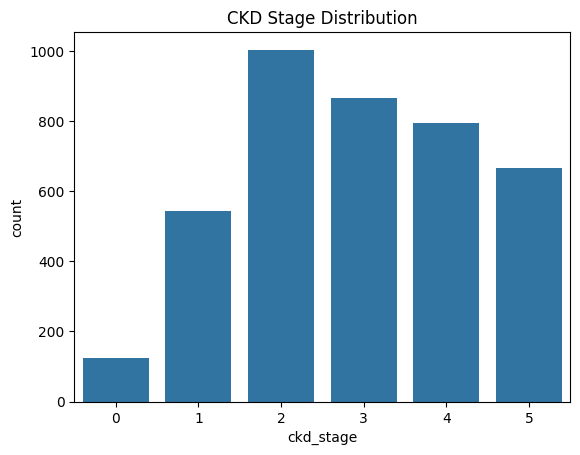

In [36]:
sns.countplot(x='ckd_stage', data=df)
plt.title('CKD Stage Distribution')

plt.savefig(BASE_DIR / "assets" / "ckd_stage_distribution.png", 
            dpi=150, bbox_inches='tight')
plt.show()

##  Target Variable Analysis (CKD Stage)
- Target column `ckd_stage` contains 6 classes: Stage 0 to Stage 5.
- Class distribution is imbalanced — Stage 0 (healthy) has only 125 records 
  while Stage 2 has 1,004 records.
- Due to class imbalance, Weighted F1-Score will be used as the primary 
  evaluation metric instead of accuracy.

# Outlier Analysis

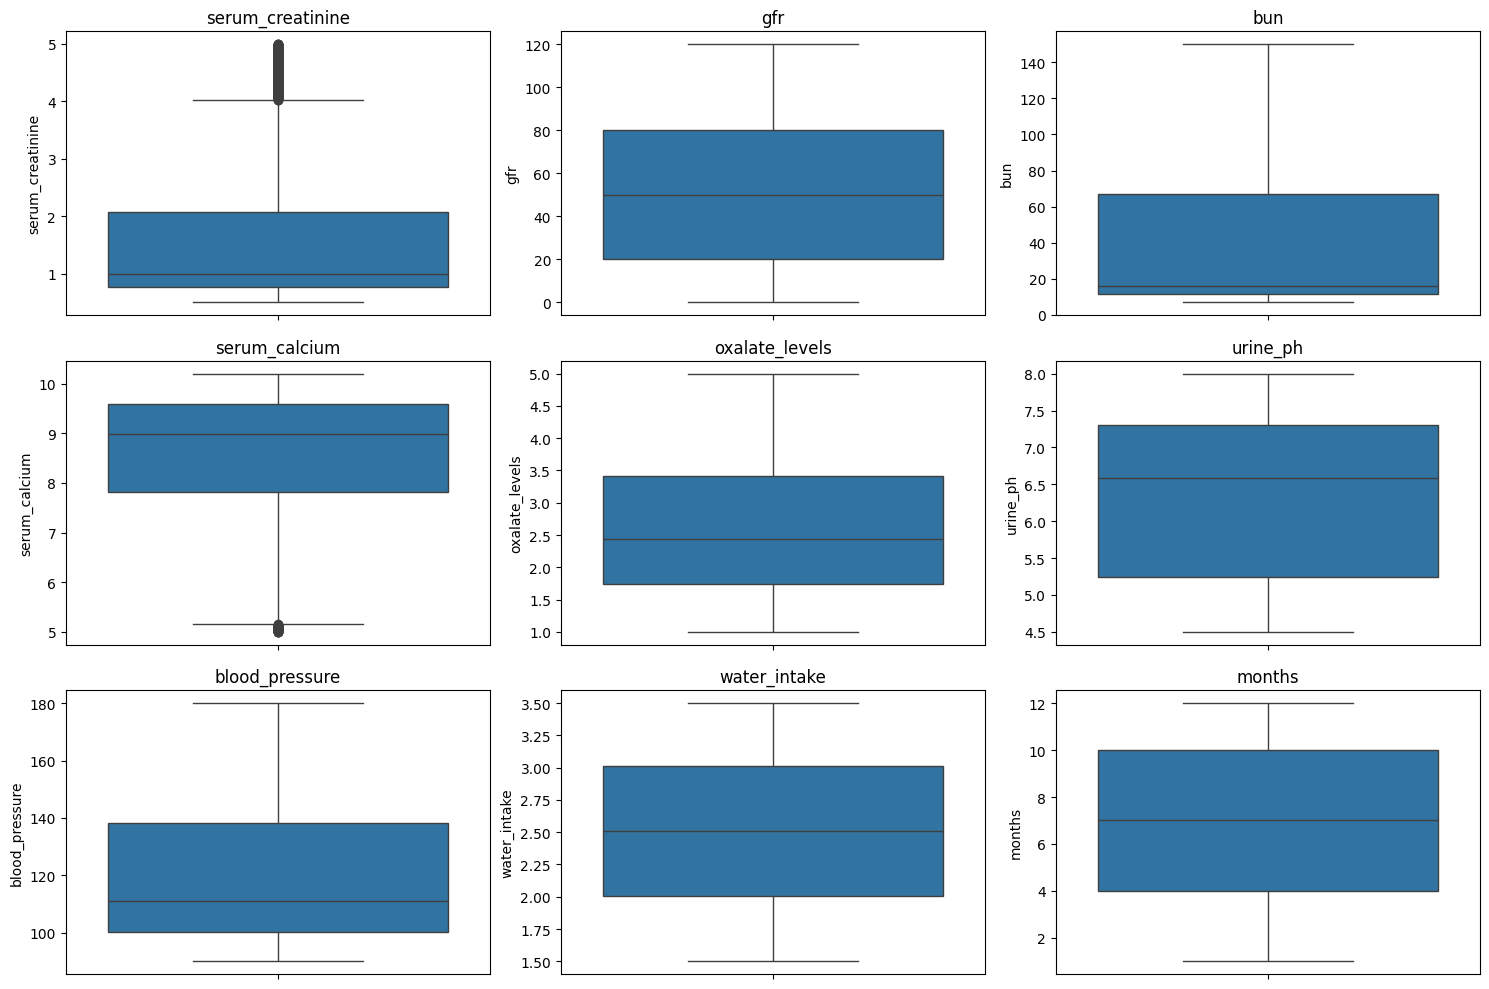

In [37]:
num_cols = ['serum_creatinine', 'gfr', 'bun', 'serum_calcium',
            'oxalate_levels', 'urine_ph', 'blood_pressure', 
            'water_intake', 'months']
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()

plt.savefig(BASE_DIR / "assets" / "outlier_boxplot.png", 
            dpi=150, bbox_inches='tight')

plt.show()

In [38]:
# Serum Creatinine outliers
Q1 = df['serum_creatinine'].quantile(0.25)
Q3 = df['serum_creatinine'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['serum_creatinine'] < lower) | 
              (df['serum_creatinine'] > upper)]

print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"Outliers count: {len(outliers)}")
print(f"Outliers CKD stages: {outliers['ckd_stage'].value_counts()}")

Lower bound: -1.20
Upper bound: 4.03
Outliers count: 311
Outliers CKD stages: ckd_stage
2    73
4    73
3    71
5    51
1    43
Name: count, dtype: int64


In [39]:
Q1 = df['serum_calcium'].quantile(0.25)
Q3 = df['serum_calcium'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_ca = df[(df['serum_calcium'] < lower) | 
                 (df['serum_calcium'] > upper)]

print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"Outliers count: {len(outliers_ca)}")
print(f"Outliers CKD stages:\n{outliers_ca['ckd_stage'].value_counts()}")

Lower bound: 5.15
Upper bound: 12.24
Outliers count: 48
Outliers CKD stages:
ckd_stage
1    16
2     9
3     8
4     8
5     7
Name: count, dtype: int64


## 4. Outlier Analysis
- Box plots reveal outliers in two numerical features:
  • serum_creatinine: 311 outliers detected above the upper whisker (IQR bound: 4.03).
    These are distributed across all CKD stages and represent clinically valid 
    high creatinine levels in advanced kidney disease patients.
  • serum_calcium: 48 outliers detected below the lower whisker (IQR bound: 5.15).
    These are spread across multiple stages and reflect medically valid calcium 
    abnormalities in CKD patients.
- Decision: No outliers removed — all values are medically justified.

## Feature–Target Analysis

In [40]:
df.groupby('ckd_stage')[['gfr', 'serum_creatinine', 'bun', 'blood_pressure']].mean()

,gfr,serum_creatinine,bun,blood_pressure
ckd_stage,,,,
0,111.301148,0.832061,13.372176,101.200124
1,103.372682,1.690890,45.997336,123.873409
2,74.943530,1.541086,39.237275,119.548462
3,45.829639,1.569990,39.659940,120.389256
4,21.215474,1.557366,38.607808,119.360780
5,7.378651,1.556667,39.414337,119.776283


## 5. Feature vs Target Relationship
- GFR is the strongest predictor — drops from 111 (Stage 0) to 7.4 (Stage 5).
- GFR correlation with ckd_stage: -0.97 — near perfect negative relationship.
- BUN, serum_creatinine, blood_pressure all elevated in CKD stages vs Stage 0.
- Lifestyle features (smoking, alcohol, stress) show indirect association with disease progression.

## Correlation Analysis

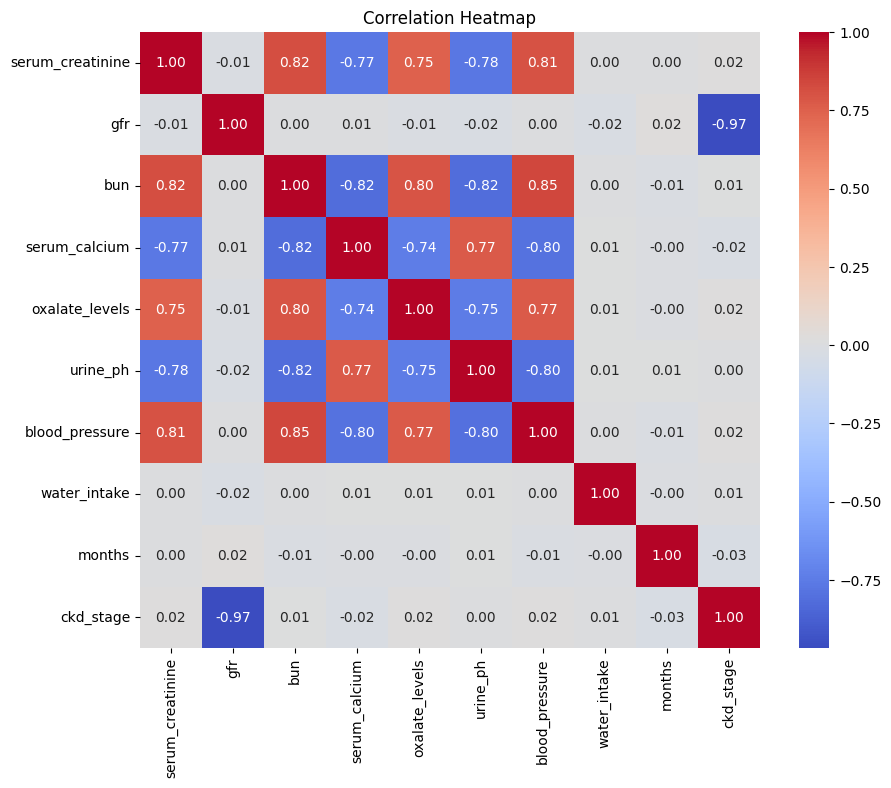

In [41]:
num_cols = ['serum_creatinine','gfr','bun','serum_calcium',
            'oxalate_levels','urine_ph','blood_pressure',
            'water_intake','months','ckd_stage']

plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.savefig(BASE_DIR / "assets" / "correlation_heatmap.png", 
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Interpretation
- Correlation heatmap reveals multicollinearity among lab features:
  • BUN & blood_pressure: 0.85
  • serum_creatinine & BUN: 0.82
  • serum_creatinine & blood_pressure: 0.81
- Decision: Multicollinearity is NOT addressed — tree-based models 
  (Random Forest, XGBoost) are inherently robust to correlated features.
- GFR shows strongest correlation with target (ckd_stage): -0.97 (negative — 
  lower GFR = higher disease stage).

## Categorical Feature Encoding

In [42]:
cat_cols = ['physical_activity', 'diet', 'smoking', 
            'alcohol', 'painkiller_usage', 'family_history', 
            'weight_changes', 'stress_level']

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

physical_activity: ['weekly' 'rarely' 'daily']
diet: ['high protein' 'low salt' 'balanced']
smoking: ['yes' 'no']
alcohol: ['daily' 'never' 'occasionally']
painkiller_usage: ['no' 'yes']
family_history: ['yes' 'no']
weight_changes: ['stable' 'loss' 'gain']
stress_level: ['low' 'moderate' 'high']


In [43]:
from sklearn.preprocessing import LabelEncoder
import joblib
import os
os.makedirs(BASE_DIR / "models" / "encoders", exist_ok=True)  # Create a directory to save encoders
# Binary columns — Label Encoding
binary_cols = ['smoking', 'painkiller_usage', 'family_history']
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(col, dict(zip(le.classes_, le.transform(le.classes_))))
    joblib.dump(le, BASE_DIR / "models" / "encoders" / f"{col}_encoder.pkl")
# Ordered columns — manual mapping
df['stress_level'] = df['stress_level'].map({'low':0, 'moderate':1, 'high':2})
df['physical_activity'] = df['physical_activity'].map({'rarely':0, 'weekly':1, 'daily':2})
# Unordered multi-value — One Hot Encoding
df = pd.get_dummies(df, columns=['diet', 'alcohol', 'weight_changes'])

smoking {'no': np.int64(0), 'yes': np.int64(1)}
painkiller_usage {'no': np.int64(0), 'yes': np.int64(1)}
family_history {'no': np.int64(0), 'yes': np.int64(1)}


In [44]:
encoded_cols = [
    'diet_balanced',
    'diet_high protein',
    'diet_low salt',
    'alcohol_daily',
    'alcohol_never',
    'alcohol_occasionally',
    'weight_changes_gain',
    'weight_changes_loss',
    'weight_changes_stable'
]

for col in encoded_cols:
    print(f"{col}:")
    print("  Data Type:", df[col].dtype)
    print("  Unique Values:", df[col].unique())
    print()

diet_balanced:
  Data Type: bool
  Unique Values: [False  True]

diet_high protein:
  Data Type: bool
  Unique Values: [ True False]

diet_low salt:
  Data Type: bool
  Unique Values: [False  True]

alcohol_daily:
  Data Type: bool
  Unique Values: [ True False]

alcohol_never:
  Data Type: bool
  Unique Values: [False  True]

alcohol_occasionally:
  Data Type: bool
  Unique Values: [False  True]

weight_changes_gain:
  Data Type: bool
  Unique Values: [False  True]

weight_changes_loss:
  Data Type: bool
  Unique Values: [False  True]

weight_changes_stable:
  Data Type: bool
  Unique Values: [ True False]



## Categorical Encoding
- Three encoding strategies applied based on feature type:
  • Binary columns (smoking, painkiller_usage, family_history): 
    Label Encoding → 0/1. Encoders saved as .pkl files for reuse in FastAPI.
  • Ordered columns (stress_level, physical_activity): 
    Manual mapping preserving natural order (low=0, moderate=1, high=2).
  • Unordered multi-value columns (diet, alcohol, weight_changes): 
    One-Hot Encoding via pd.get_dummies() — 9 new binary columns created.
- Final processed dataset saved to: data/processed/processed_ckd.csv

## Final Preprocessing Validation

In [45]:
print("Final Dataset Shape:", df.shape)

print("\nTotal Missing Values:",
      df.isnull().sum().sum())

print("\nTotal Duplicate Rows:",
      df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nFinal Columns:")
print(df.columns.tolist())

Final Dataset Shape: (4000, 27)

Total Missing Values: 0

Total Duplicate Rows: 0

Data Types:
serum_creatinine         float64
gfr                      float64
bun                      float64
serum_calcium            float64
ana                        int64
c3_c4                    float64
hematuria                  int64
oxalate_levels           float64
urine_ph                 float64
blood_pressure           float64
physical_activity          int64
water_intake             float64
smoking                    int64
painkiller_usage           int64
family_history             int64
stress_level               int64
months                     int64
ckd_stage                  int64
diet_balanced               bool
diet_high protein           bool
diet_low salt               bool
alcohol_daily               bool
alcohol_never               bool
alcohol_occasionally        bool
weight_changes_gain         bool
weight_changes_loss         bool
weight_changes_stable       bool
dtype: object


In [46]:
ohe_cols = ['diet_balanced', 'diet_high protein', 'diet_low salt',
            'alcohol_daily', 'alcohol_never', 'alcohol_occasionally',
            'weight_changes_gain', 'weight_changes_loss', 'weight_changes_stable']
df[ohe_cols] = df[ohe_cols].astype(int)
df.head()

,serum_creatinine,gfr,bun,serum_calcium,ana,c3_c4,hematuria,oxalate_levels,urine_ph,blood_pressure,...,ckd_stage,diet_balanced,diet_high protein,diet_low salt,alcohol_daily,alcohol_never,alcohol_occasionally,weight_changes_gain,weight_changes_loss,weight_changes_stable
0,0.683683,32.946784,7.553739,10.039896,0,138.204989,0,2.878164,7.864308,115.224217,...,3,0,1,0,1,0,0,0,0,1
1,3.809044,32.685035,141.347494,8.330543,1,24.282343,1,4.767639,4.920015,130.143900,...,3,0,1,0,1,0,0,0,1,0
2,1.143827,2.079805,15.979104,9.419229,0,163.970666,0,1.818613,6.188115,98.026072,...,5,0,0,1,1,0,0,0,0,1
3,4.804657,109.871407,53.307333,7.556631,1,71.056846,1,4.051686,5.278607,142.166650,...,1,0,0,1,0,1,0,0,0,1
4,4.920235,42.214590,134.182157,7.289379,1,23.384639,1,3.240920,4.862923,151.962572,...,3,1,0,0,0,0,1,1,0,0


In [47]:
# Feature columns 
feature_columns = df.drop(columns=['ckd_stage']).columns.tolist()
joblib.dump(feature_columns, BASE_DIR / "models" / "feature_columns.pkl")
print(f"Feature columns saved: {len(feature_columns)} features")
print(feature_columns)

Feature columns saved: 26 features
['serum_creatinine', 'gfr', 'bun', 'serum_calcium', 'ana', 'c3_c4', 'hematuria', 'oxalate_levels', 'urine_ph', 'blood_pressure', 'physical_activity', 'water_intake', 'smoking', 'painkiller_usage', 'family_history', 'stress_level', 'months', 'diet_balanced', 'diet_high protein', 'diet_low salt', 'alcohol_daily', 'alcohol_never', 'alcohol_occasionally', 'weight_changes_gain', 'weight_changes_loss', 'weight_changes_stable']


In [48]:
# Move 'ckd_stage' to the last column
# First, take all columns except 'ckd_stage'
# Then, add 'ckd_stage' at the end of the list
cols = [c for c in df.columns if c != 'ckd_stage'] + ['ckd_stage']

# Reorder the DataFrame columns according to the new column order
df = df[cols]

# Save the processed DataFrame as a CSV file
df.to_csv(BASE_DIR / "data" / "processed" / "processed_ckd.csv", index=False)

## EDA & Preprocessing Complete 

| Step | Status |
|------|--------|
| Data Loading | ✅ 4,000 rows × 21 columns (raw) → 27 columns after encoding |
| Missing Values | ✅ Zero |
| Duplicates | ✅ Zero |
| Outliers | ✅ Retained — medically valid |
| Target Distribution | ✅ Imbalanced — F1 Score selected |
| Correlation Analysis | ✅ GFR = strongest predictor (-0.97) |
| Categorical Encoding | ✅ Label + Map + OHE applied |
| Processed Data Saved | ✅ data/processed/processed_ckd.csv |

**Next Step:** Model Training — `02_model_training.ipynb`